# 06 — Convergence & Runtime (phụ lục)

Thực hiện **Section 9**: vẽ hội tụ theo `Timestamp_ms` (không theo iteration),
cho 3 instance đại diện nhóm C/R/RC, median/IQR qua seed. Kết quả này để
**phần phụ lục / appendix**, KHÔNG dùng để claim "FULL nhanh hơn" vì hai
variant không chạy cùng wall-clock budget.


In [1]:
# ==== CẤU HÌNH ĐƯỜNG DẪN (chỉnh lại cho đúng máy của bạn) ====
import sys, os
sys.path.append(os.path.abspath("."))  # để import evrp_analysis_utils.py cùng thư mục

FULL_DIR  = "benchmark/full"     # thư mục kết quả bản đầy đủ (equity-aware)
NOEQ_DIR  = "benchmark/no-EQ"    # thư mục kết quả bản loại equity guidance
ARTIFACT_DIR = "artifacts"       # nơi lưu các bảng trung gian (csv) giữa các notebook
os.makedirs(ARTIFACT_DIR, exist_ok=True)

import pandas as pd
import numpy as np
import evrp_analysis_utils as utils

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 160)


In [2]:
manifest = pd.read_csv(f"{ARTIFACT_DIR}/run_manifest_matched_valid.csv")


## 6.1. Chọn 3 instance đại diện (một mỗi nhóm C / R / RC)

In [3]:
groups_available = manifest["Group"].dropna().unique()
print("Nhóm instance tìm thấy:", groups_available)

representative = {}
for grp in ["C", "R", "RC"]:
    cand = manifest[manifest["Group"] == grp]
    if not cand.empty:
        representative[grp] = cand["Instance"].iloc[0]
print("Instance đại diện:", representative)


Nhóm instance tìm thấy: ['C' 'R' 'RC']
Instance đại diện: {'C': 'c101_21', 'R': 'r101_21', 'RC': 'rc101_21'}


## 6.2. Đọc `_progress.csv` cho instance đại diện, cả hai variant, tất cả seed

In [4]:
def load_progress_for_instance(instance, manifest):
    rows = manifest[manifest["Instance"] == instance]
    frames = []
    for _, run in rows.iterrows():
        path = os.path.join(run["RunDir"], f"{run['Instance']}_seed_{int(run['Seed'])}_progress.csv")
        df = utils.parse_progress(path)
        if df.empty:
            continue
        df["Variant"] = run["Variant"]
        df["Seed"] = run["Seed"]
        frames.append(df)
    return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()

progress_by_group = {grp: load_progress_for_instance(inst, manifest) for grp, inst in representative.items()}
{grp: len(df) for grp, df in progress_by_group.items()}


{'C': 1452, 'R': 2036, 'RC': 2052}

## 6.3. Median/IQR theo Timestamp_ms cho BestDistance, BestWorkloadGini, BestMaxTime

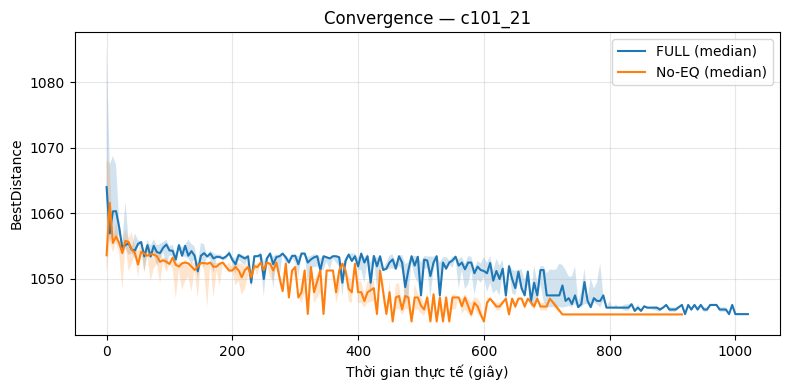

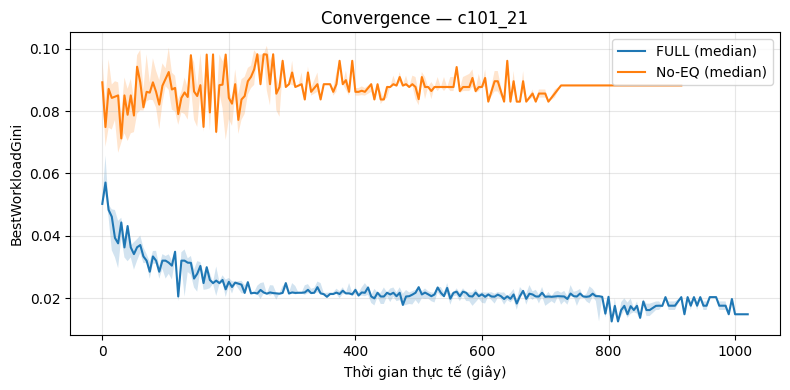

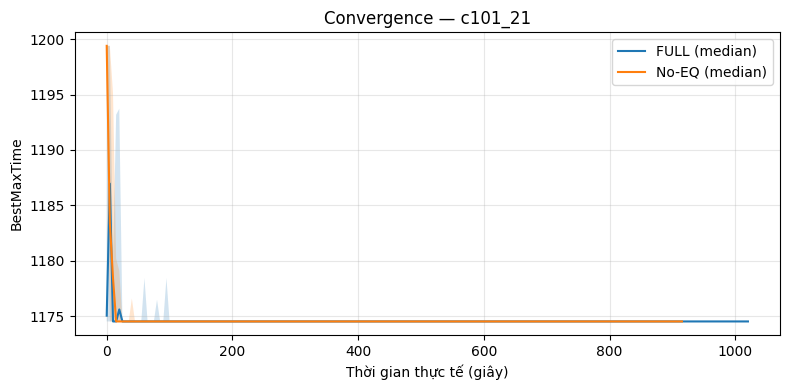

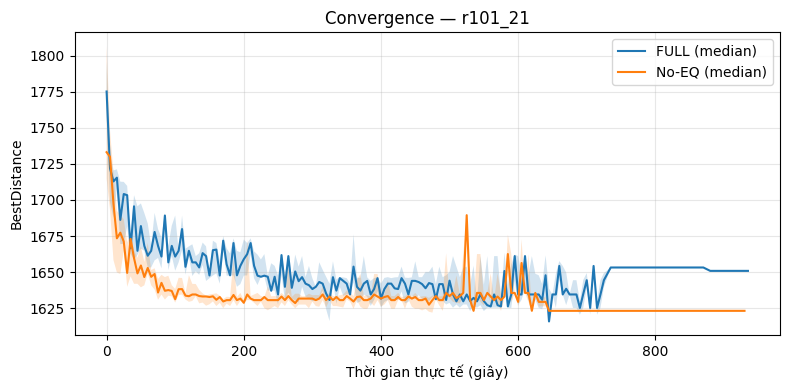

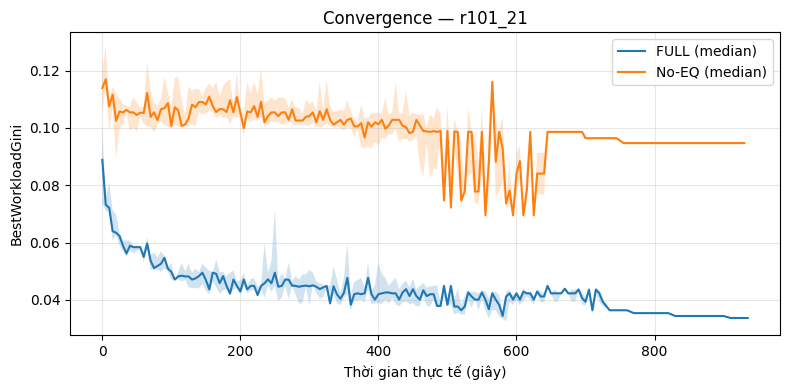

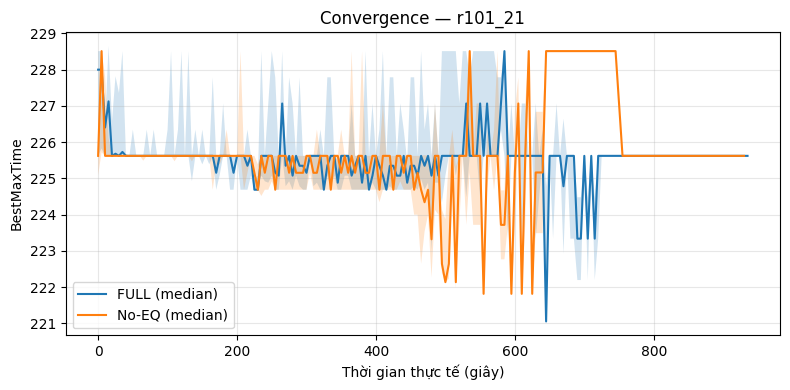

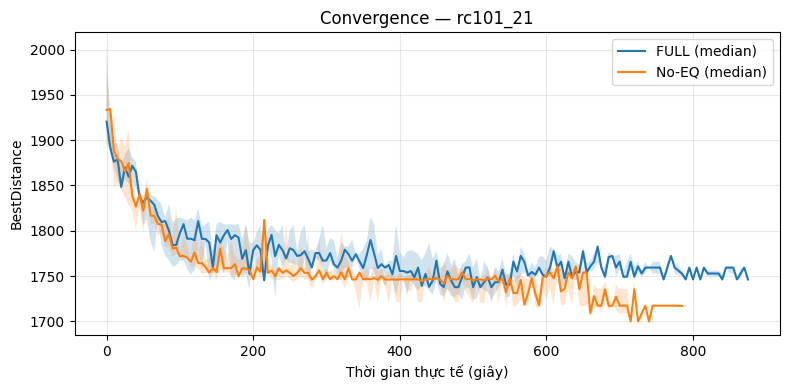

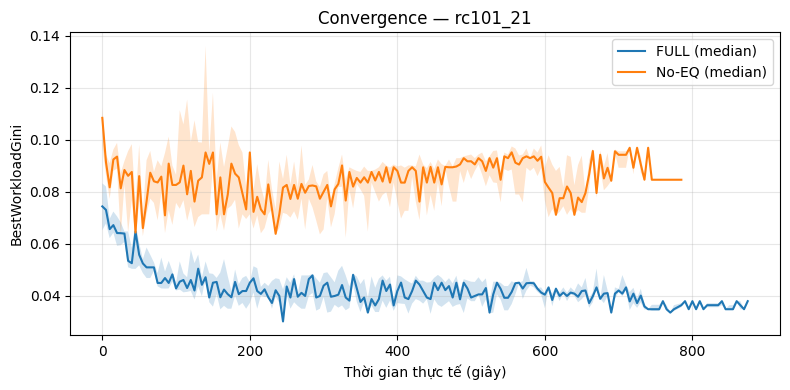

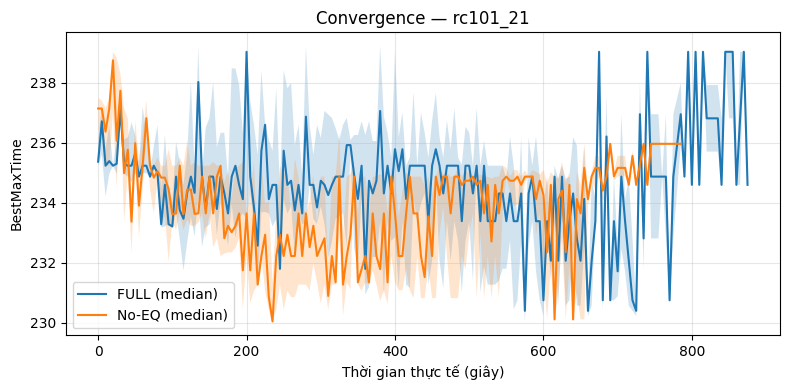

In [5]:
import matplotlib.pyplot as plt

METRICS = [c for c in ["BestDistance", "BestWorkloadGini", "BestMaxTime"] if True]

def plot_convergence(df, instance_name, metric):
    if df.empty or metric not in df.columns:
        print(f"Thiếu dữ liệu cho {instance_name} / {metric}")
        return
    fig, ax = plt.subplots(figsize=(8, 4))
    for variant, g in df.groupby("Variant"):
        # bin theo timestamp để tính median/IQR qua seed
        g = g.copy()
        g["T_bin"] = (g["Timestamp_ms"] // 5000) * 5000  # bin 5 giây
        stats = g.groupby("T_bin")[metric].agg(["median",
                                                  lambda s: s.quantile(0.25),
                                                  lambda s: s.quantile(0.75)])
        stats.columns = ["median", "q25", "q75"]
        ax.plot(stats.index / 1000, stats["median"], label=f"{variant} (median)")
        ax.fill_between(stats.index / 1000, stats["q25"], stats["q75"], alpha=0.2)
    ax.set_xlabel("Thời gian thực tế (giây)")
    ax.set_ylabel(metric)
    ax.set_title(f"Convergence — {instance_name}")
    ax.legend()
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(f"{ARTIFACT_DIR}/fig_convergence_{instance_name}_{metric}.png", dpi=150)
    plt.show()

for grp, inst in representative.items():
    df = progress_by_group[grp]
    for metric in METRICS:
        if metric in df.columns:
            plot_convergence(df, inst, metric)


## 6.4. Runtime overhead (báo cáo như *cost*, không phải headline result)

In [6]:
runtime_overhead = (
    manifest.groupby(["Instance", "Variant"])["Runtime_s"].mean().unstack()
)
if {"FULL", "No-EQ"}.issubset(runtime_overhead.columns):
    runtime_overhead["Overhead_pct"] = (runtime_overhead["FULL"] / runtime_overhead["No-EQ"] - 1) * 100
    print(runtime_overhead["Overhead_pct"].describe())
    runtime_overhead.to_csv(f"{ARTIFACT_DIR}/runtime_overhead.csv")
runtime_overhead.head()


count     92.000000
mean      28.466378
std       77.593708
min      -59.877133
25%       -0.229211
50%       12.208931
75%       37.386381
max      657.070849
Name: Overhead_pct, dtype: float64


Variant,FULL,No-EQ,Overhead_pct
Instance,,,
c101C10,3.2926,2.6577,23.889077
c101C5,0.7687,0.3788,102.930306
c101_21,824.1884,385.7782,113.643073
c102_21,595.2374,586.3886,1.509033
c103C15,7.3131,4.9255,48.474267
